# 02 — Descriptive EDA from the Data Warehouse

**Proyecto:** Clasificación de ventana terapéutica en ACV isquémico — Fundación Valle del Lilí.
**Fase:** 4 — EDA descriptivo (leyendo del DW, no del CSV).
**Documento maestro:** [`../agent.md`](../agent.md).

## Objetivo

Caracterizar la cohorte **a nivel paciente** usando las tablas del DW (`analytics.dim_patient`, `analytics.fct_slice`, `analytics.agg_patient`). Outputs visuales de la distribución de variables clínicas y radiómicas por clase de ventana.

## Diferencias con el notebook 01

- 01 confirmaba la realidad cruda del CSV.
- 02 **construye la narrativa clínica** a partir del DW: ¿en qué se diferencian visualmente los pacientes con ventana ≤4.5h vs >4.5h?
- 02 NO hace inferencia estadística — eso vive en notebook 03.

Las figuras se persisten en `reports/figures/eda_descriptive_*.png` y alimentan el dashboard final.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from acv.config import settings
from acv.io.db import get_engine

FIG = settings.project_root / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

np.random.seed(settings.random_seed)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

engine = get_engine()
print("Connected to DW.")

Connected to DW.


## § 1 — Pulled cohort

Carga única desde `analytics.agg_patient` (74 filas, una por paciente) más algunos agregados que no están materializados aún. Mantener la lectura en **un solo round-trip** mantiene el notebook rápido y disminuye el riesgo de inconsistencias entre vistas.

In [2]:
with engine.connect() as conn:
    patients = pd.read_sql(text("SELECT * FROM analytics.agg_patient"), conn)
    slices = pd.read_sql(
        text(
            "SELECT f.patient_sk, f.dataset_origin, f.is_over_window, "
            "       f.shape2d_meshsurface, f.shape2d_maximumdiameter, "
            "       f.firstorder_entropy, f.firstorder_mean, "
            "       f.glcm_contrast, f.glszm_zoneentropy "
            "FROM analytics.fct_slice f"
        ),
        conn,
    )

print("patients :", patients.shape)
print("slices   :", slices.shape)
print()
print("class balance (patient-level):")
print(patients.groupby(["dataset_origin", "is_over_window"]).size().unstack(fill_value=0))

patients : (74, 22)
slices   : (2820, 9)

class balance (patient-level):
is_over_window   0   1
dataset_origin        
test            11   8
train           39  16


## § 2 — Demografía y clínicas básicas, segmentadas por clase

¿Hay diferencias visuales obvias entre los pacientes con `is_over_window=0` (≤4.5h, elegibles) vs `is_over_window=1` (>4.5h, fuera de ventana)? Si no las hay, el modelo va a apoyarse exclusivamente en las radiómicas — lo cual es **exactamente** la pregunta de investigación del proyecto.

Cohort summary (patient-level):


               age_years                         nihss                         \
                   count    mean     std  median count    mean    std  median   
is_over_window                                                                  
0                     50 68.8200 14.9120 72.0000    48 12.0420 6.3580 11.5000   
1                     24 65.7080 17.5310 69.5000    21 10.1900 8.5240  8.0000   

               aspects                      n_slices                          \
                 count   mean    std median    count    mean     std  median   
is_over_window                                                                 
0                   44 8.5910 1.6750 9.0000       50 33.8400 25.3230 26.0000   
1                   21 7.7140 2.2170 8.0000       24 47.0000 31.6320 39.0000   

               lesion_max_area                               lesion_avg_area  \
                         count      mean       std    median           count   
is_over_window                  

C:\Users\andre\AppData\Local\Temp\ipykernel_28912\4051188853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")
C:\Users\andre\AppData\Local\Temp\ipykernel_28912\4051188853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")
C:\Users\andre\AppData\Local\Temp\ipykernel_28912\4051188853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")


C:\Users\andre\AppData\Local\Temp\ipykernel_28912\4051188853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")
C:\Users\andre\AppData\Local\Temp\ipykernel_28912\4051188853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")
C:\Users\andre\AppData\Local\Temp\ipykernel_28912\4051188853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")
C:\Users\a

C:\Users\andre\AppData\Local\Temp\ipykernel_28912\4051188853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")
C:\Users\andre\AppData\Local\Temp\ipykernel_28912\4051188853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")
C:\Users\andre\AppData\Local\Temp\ipykernel_28912\4051188853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")
C:\Users\a

C:\Users\andre\AppData\Local\Temp\ipykernel_28912\4051188853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")


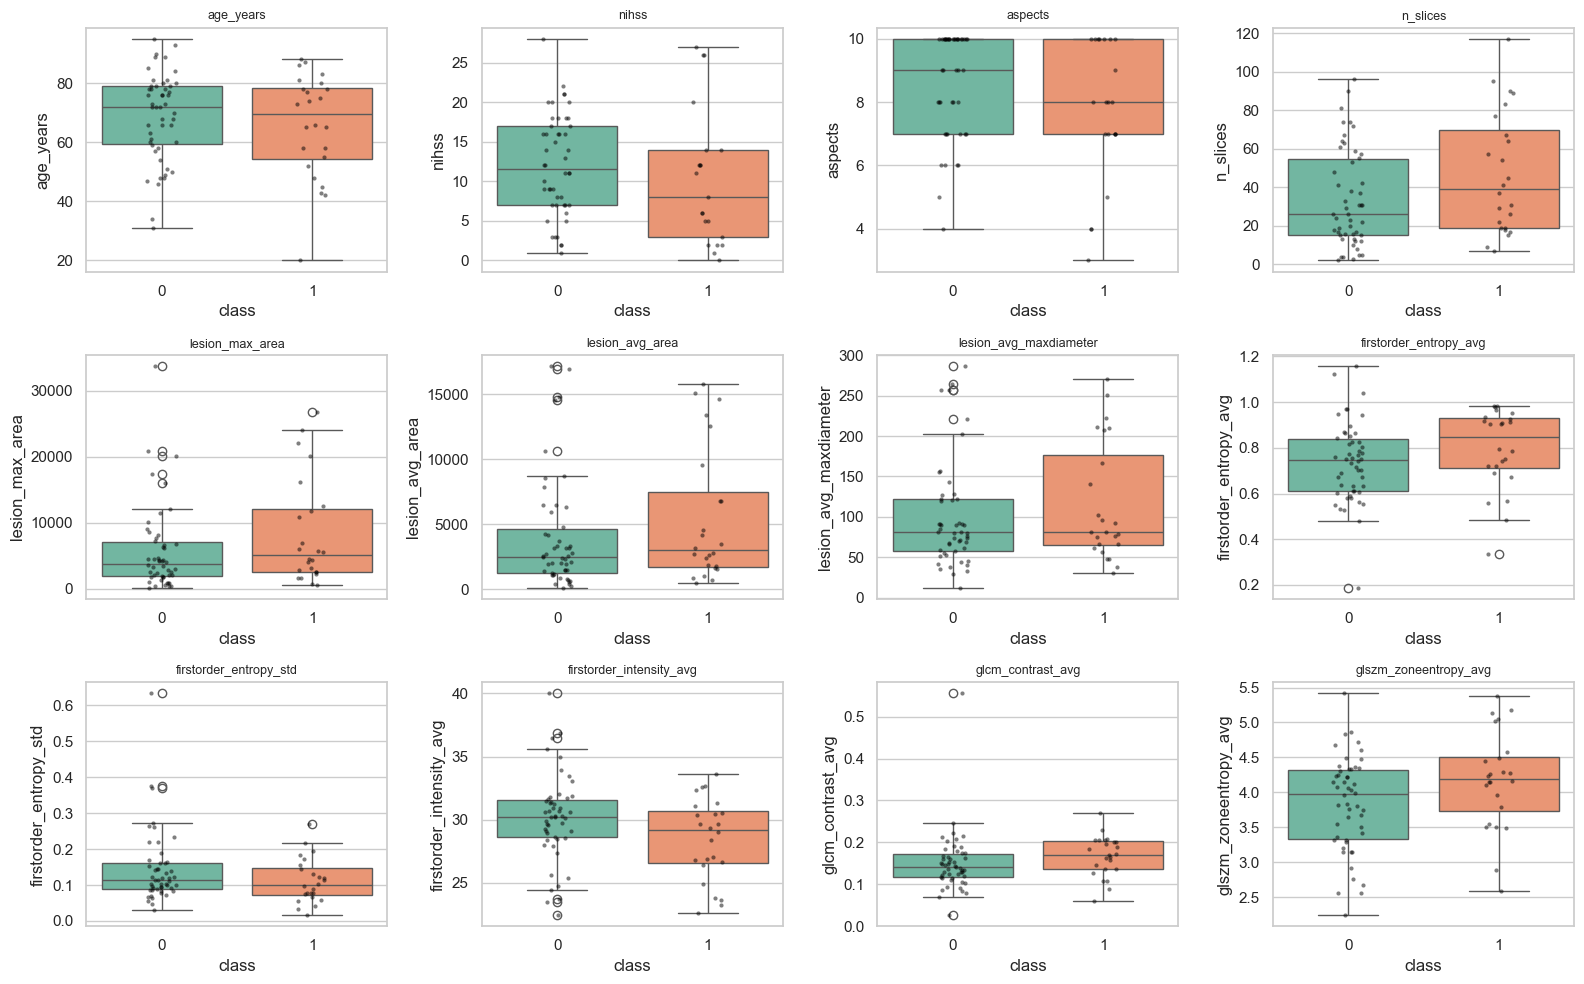

In [3]:
clinical_cols = ["age_years", "nihss", "aspects", "n_slices",
                 "lesion_max_area", "lesion_avg_area", "lesion_avg_maxdiameter",
                 "firstorder_entropy_avg", "firstorder_entropy_std",
                 "firstorder_intensity_avg", "glcm_contrast_avg", "glszm_zoneentropy_avg"]

summary = (
    patients.groupby("is_over_window")[clinical_cols]
    .agg(["count", "mean", "std", "median"])
    .round(3)
)
print("Cohort summary (patient-level):")
print(summary)

fig, axs = plt.subplots(3, 4, figsize=(16, 10), sharey=False)
axs = axs.ravel()
for ax, col in zip(axs, clinical_cols):
    sns.boxplot(data=patients, x="is_over_window", y=col, ax=ax, palette="Set2")
    sns.stripplot(data=patients, x="is_over_window", y=col, ax=ax, color="black", alpha=0.5, size=3)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("class")
plt.tight_layout()
plt.savefig(FIG / "eda_descriptive_01_box_by_class.png", dpi=120)
plt.show()

## § 3 — Correlación entre agregados a nivel paciente

Una matriz de correlación rápida sobre las clínicas + radiómicas agregadas. Buscamos:
- features fuertemente correlacionadas entre sí (candidatas a fusionar/eliminar en Fase 5).
- features con correlación notable con el target (candidatas a entrar al baseline clínico de Fase 6).

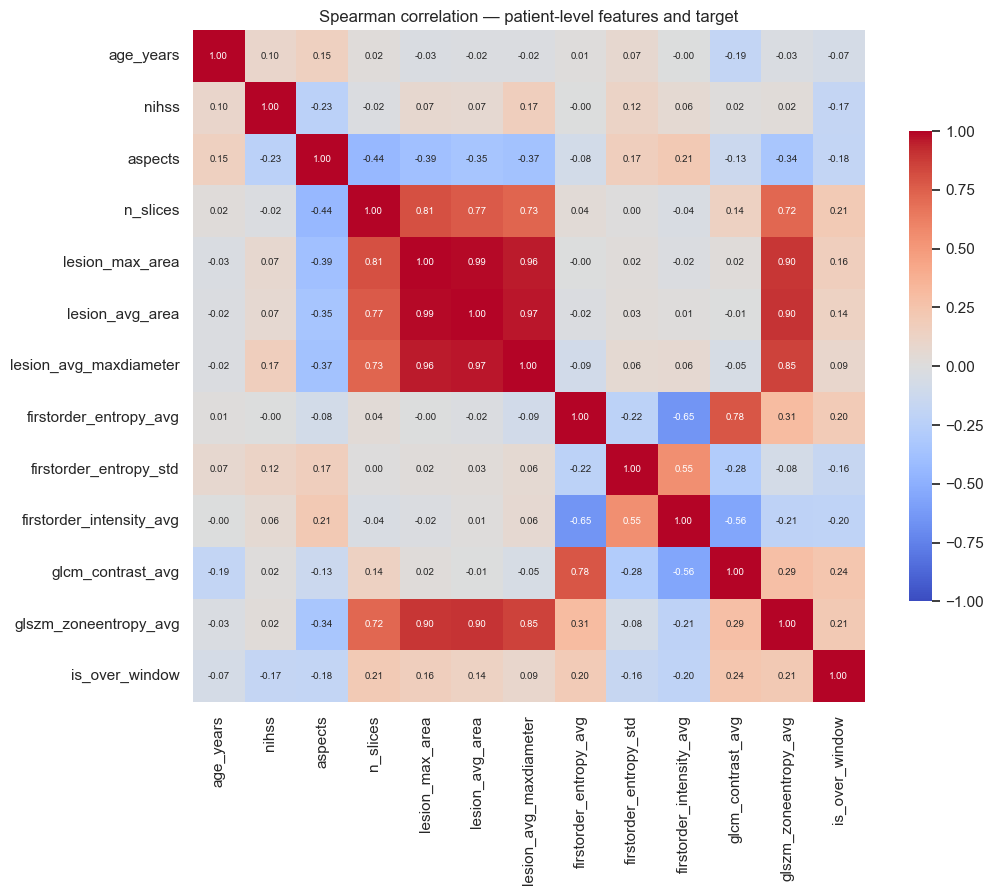

Top |corr| with target:
glcm_contrast_avg          0.2370
glszm_zoneentropy_avg      0.2120
n_slices                   0.2080
firstorder_intensity_avg   0.2040
firstorder_entropy_avg     0.1970
aspects                    0.1830
nihss                      0.1740
lesion_max_area            0.1650
firstorder_entropy_std     0.1580
lesion_avg_area            0.1390
lesion_avg_maxdiameter     0.0860
age_years                  0.0680
Name: is_over_window, dtype: float64


In [4]:
corr_cols = clinical_cols + ["is_over_window"]
corr = patients[corr_cols].corr(method="spearman")  # robust to non-normality

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, square=True, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Spearman correlation — patient-level features and target")
plt.tight_layout()
plt.savefig(FIG / "eda_descriptive_02_corr.png", dpi=120)
plt.show()

print("Top |corr| with target:")
print(corr["is_over_window"].drop("is_over_window").abs().sort_values(ascending=False).round(3))

## § 4 — PCA: ¿se separan visualmente las clases en 2D?

Si las dos clases forman nubes separadas en una proyección PCA de los agregados radiómicos, el problema "probablemente" se puede resolver con un modelo lineal sencillo. Si están mezcladas, vamos a necesitar modelos no lineales y combinaciones de features.

PCA se calcula sobre features radiómicas + clínicas, **excluyendo la columna leakage** `evolution_hours/minutes` y el target.

Explained variance: PC1=40.2%  PC2=16.3%  total=56.5%


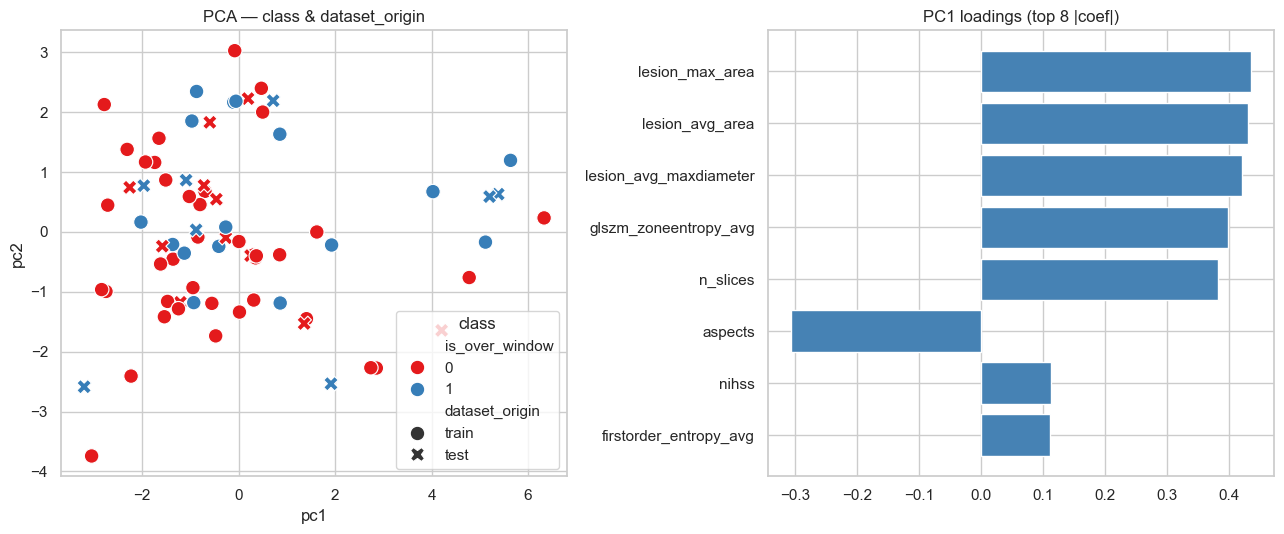

In [5]:
pca_cols = [c for c in clinical_cols if c not in ("evolution_minutes", "evolution_hours")]
X = patients[pca_cols].copy()
X = X.fillna(X.median(numeric_only=True))

X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=settings.random_seed)
Z = pca.fit_transform(X_std)
patients["pc1"] = Z[:, 0]
patients["pc2"] = Z[:, 1]

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%  "
      f"total={pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
sns.scatterplot(data=patients, x="pc1", y="pc2", hue="is_over_window",
                style="dataset_origin", s=110, ax=ax[0], palette="Set1")
ax[0].set_title("PCA — class & dataset_origin")
ax[0].legend(title="class")

# top loadings of PC1
loadings = pd.DataFrame({"feature": pca_cols,
                         "pc1_loading": pca.components_[0],
                         "pc2_loading": pca.components_[1]})
loadings["abs_pc1"] = loadings["pc1_loading"].abs()
top = loadings.sort_values("abs_pc1", ascending=False).head(8)
ax[1].barh(top["feature"], top["pc1_loading"], color="steelblue")
ax[1].set_title("PC1 loadings (top 8 |coef|)")
ax[1].invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / "eda_descriptive_03_pca.png", dpi=120)
plt.show()